# [LAB-7] 2. 가설검정의 이해

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import my_plot, my_stats
from pandas import melt, DataFrame

# 가설 검정의 가정에 필요한 패키지
from scipy.stats import shapiro, skew, kurtosis, normaltest, bartlett, levene

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터 가져오기

- 동일한 제품을 판매하고 있는 서로 다른 두 지역의 매장의 100일간의 일별 매출액을 기록한 가상의 데이터
    - 이 데이터를 사용하여 두 매장의 평균 매출액을 비교하고자 한다.
    - 수집된 데이터가 평균 비교에 적합한지 알아보라.

In [2]:
origin = load_data("two_store")
origin.head()

📚 동일한 제품을 판매하고 있는 서로 다른 두 지역의 매장의 100일간의 일별 매출액을 기록한 가상의 데이터 (출처: 방송통신대학교 통계학개론)


,store1,store2
0,34,63
1,63,85
2,57,75
3,50,48
4,37,58


## #02. 시각화를 통한 데이터 분포 확인

### 1. 커널밀도 그래프를 위한 데이터 재배치

- 가설검정을 통해 평균을 비교하기 위해서는 정규성을 충족해야 한다.
    - 정규 분포 확인을 커널밀도함수 그래프를 통해 전반적인 데이터의 분포를 확인할 수 있다.
    - 정규분포를 충족하는 데이터는 시각화의 모양이 좌우 대칭인 상태로 봉긋하게 나타나야 한다.

In [3]:
df = melt(origin, var_name="store", value_name="sales")
df.head()

,store,sales
0,store1,34
1,store1,63
2,store1,57
3,store1,50
4,store1,37


### 2. 데이터 분포 시각화

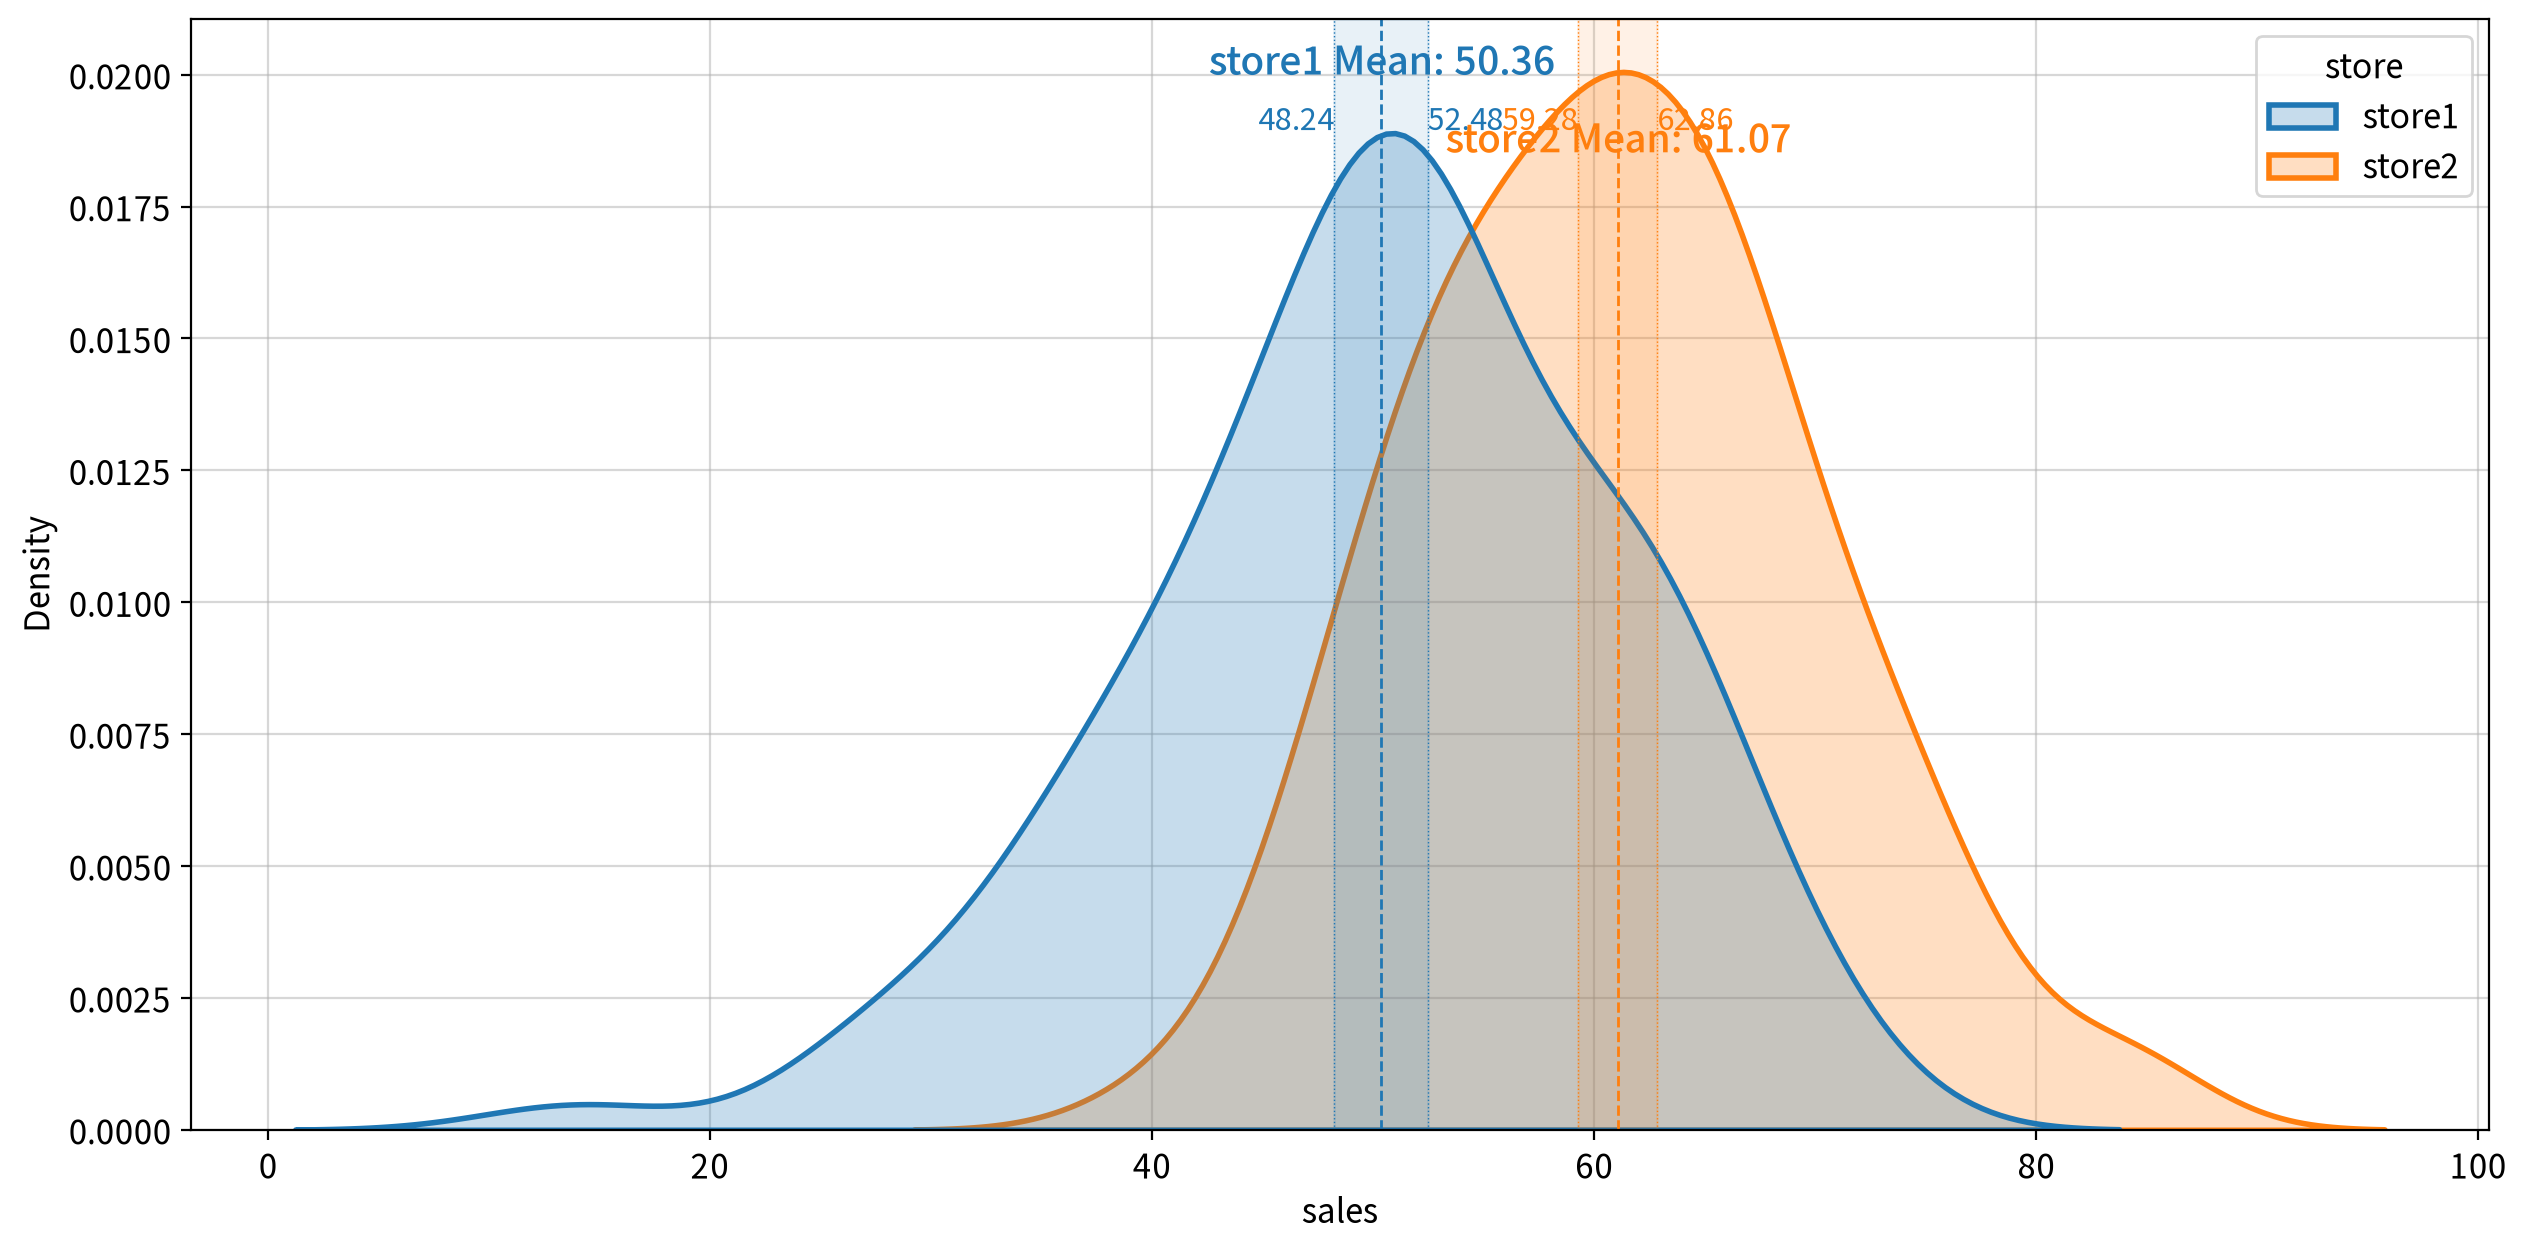

In [4]:
my_plot.kdeplot(df, x="sales", hue="store", 
                meanline=True, clevel=0.95, fill=True)

#### 💡 인사이트 요약

- **정규성**: 두 집단 모두 큰 왜곡 없이 종 모양이라 정규성 가정은 대체로 무난함.
- **등분산성**: 두 분포의 퍼짐이 비슷해 보이므로 등분산 가정도 크게 문제 없어 보임.
- **독립성**: 이 그림만으로는 확인 불가함. 수집 구조를 따로 봐야 함.

> 그런데... 확실한건가?

## #03. 통계량을 통한 데이터 정규성 확인

### 1. Shapiro Wilk 검정 (1) - store1에 대한 검정

Shapiro Wilk 검정은 매우 엄격하고 이를 충족하기 위해서는 이상치가 없어야 하며 좌우 대칭도 거의 완전해야 하기 때문에 현실에서 이 기준에 맞는 데이터는 없다고 보는 것이 맞다.

| 가설 | 내용 | 설명 |
|---|---|---|
| 귀무가설($H_0$) | $P \geq 0.05$ | 데이터 분포와 정규분포는 차이가 없다 (정규성을 따름) |
| 대립가설($H_1$) | $P < 0.05$ | 데이터 분포와 정규분포는 차이가 있다 (정규성을 따름) |

In [5]:
normal_tmpl = "statistic: {0:.3f}, p-value: {1:.3f}, 정규성 충족 여부: {2}"

In [6]:
s, p = shapiro(origin['store1'])
normal_tmpl.format(s, p, p >= 0.05)

'statistic: 0.979, p-value: 0.109, 정규성 충족 여부: True'

### 2. Shapiro Wilk 검정 (2) - store2에 대한 검정

In [7]:
s, p = shapiro(origin['store2'])
normal_tmpl.format(s, p, p >= 0.05)

'statistic: 0.991, p-value: 0.731, 정규성 충족 여부: True'

### 3. Normal Test - store1에 대한 검정

- $|왜도| < 2$, $|첨도| < 7$이면 정규분포에서 크게 벗어나지 않아 정규성을 충족한다(West, 1995).
- Shapiro 검정에 비해 느슨한 기준이기 때문에 많은 논문에서 많이 인용되고 있다.

In [8]:
s, p = normaltest(origin['store1'])
normal_tmpl.format(s, p, p >= 0.05)

'statistic: 5.651, p-value: 0.059, 정규성 충족 여부: True'

> `p-value`가 `0.059`이므로 ($p > 0.05$) store1의 매출 데이터는 정규성을 따른다.

### 4. Normal Test - store2에 대한 검정

In [9]:
s, p = normaltest(origin['store2'])
normal_tmpl.format(s, p, p >= 0.05)

'statistic: 1.174, p-value: 0.556, 정규성 충족 여부: True'

> `p-value`가 `0.556`이므로 ($p>0.05$) store1의 매출 데이터는 정규성을 따른다.

## #04. 통계량을 통한 등분산성 확인

### 1. Bartlett 검정

- 모든 변수가 정규성을 충족할 경우 사용
- 정수형이 아닌 실수형 타입을 사용해야 한다.

| 가설 | 내용 | 설명 |
|---|---|---|
| 귀무가설($H_0$) | $P \geq 0.05$ | 집단간 분산의 차이가 없다 |
| 대립가설($H_1$) | $P < 0.05$ | 집단간 분산의 차이가 있다 |

In [10]:
var_tmpl = "statistic: {0:.3f}, p-value: {1:.3f}, 등분산성 충족 여부: {2}"

In [11]:
s, p = bartlett(origin['store1'].astype('float'), 
                origin['store2'].astype('float'))
var_tmpl.format(s, p, p >= 0.05)

'statistic: 2.844, p-value: 0.092, 등분산성 충족 여부: True'

### 2. Levene 검정

- 비교 대상 데이터중 하나라도 정규분포를 따르지 않을 경우 사용
    - 이 예제의 데이터에서는 적합하지 않은 방법이지만 여기서는 코드의 전개 과정을 제시하기 위해 사용함
- `center` 파라미터는 비교할 기준 설정
    - 레빈 검정의 기본값은 평균을 비교하는 것이지만 실무에서는 중앙값을 비교하는 것이 더 효용성이 높음

In [12]:
# 파라미터 수의 제한이 없다.
s, p = levene(origin['store1'], origin['store2'], 
              center='median')
var_tmpl.format(s, p, p >= 0.05)

'statistic: 1.360, p-value: 0.245, 등분산성 충족 여부: True'

## #04. 모듈화 기능 확인

### 1. 가설검정의 가정 일괄 확인

In [13]:
# 정규성을 충족하는 데이터 → Bartlett 검정이 선택됨
# columns 인자를 지정하지 않으면 수치형 컬럼 전체에 대해 검정이 수행됨
my_stats.test_assumptions(origin, columns=["store1", "store2"])

,test,statistic,p-value,result
field,,,,
store1,normaltest,5.651,0.059,True
store2,normaltest,1.174,0.556,True
Bartlett,equal_var,2.844,0.092,True
